#  atoMLtype ModelOutput Analysis

In this tutorial, we’ll dive deep into the analysis tools provided by the `PredictionRecord` interface of the ModelOutput in this project. This includes:

- Error diagnosis (accuracy, mismatches, confidence)
- Visual analysis (heatmaps, confusion matrices, model embeddings)
- Atom-specific inspection and molecule rendering

These tools are designed to help you understand where your model succeeds, where it fails, and why.

## Load molecules, train model and perform inference.

Before introducing the analysis tools, we will repeat the process of building our model and performing inference from the "Tutorial_quickstart.ipynb"

In [1]:
from torch.utils.data import random_split
import numpy as np
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("dataset_loader.log"),
        logging.StreamHandler()
    ]
)


from atoMLtype.datasets.GNNdataset import GNNdataset
from atoMLtype.models.ModelEncoder import ModelEncoder
from atoMLtype.analysis.accuracy_counts import plot_atom_distribution
from atoMLtype.models.GNN.DMPNNmodel import AtomBondMPNN
from atoMLtype.models.ModelTrainer import GNNTrainer
from atoMLtype.models.ModelEngine import ModelEngine


[2025-04-29 18:03:23,862] INFO - Enabling RDKit 2024.03.5 jupyter extensions
[2025-04-29 18:03:24,502] INFO - NumExpr defaulting to 10 threads.


In [2]:
dataset_encoder = ModelEncoder(collapse=True)

In [3]:
# Load the ZINC files
zinc_sdf_path = "./data/parm_at_Frosst/zinc.sdf"
zinc_json_labels = "./data/antechamber/atomLabels_gaff2.json"

zinc_dataset = GNNdataset(sdf_path=zinc_sdf_path, 
                          label_path=zinc_json_labels, 
                          directed_graph=True,
                          labeled=True,
                          encoder=dataset_encoder)

[2025-04-29 18:03:25,118] INFO - Loaded atom type labels for 6410 molecules from ./data/antechamber/atomLabels_gaff2.json
[2025-04-29 18:03:25,154] WARNING - Atom count mismatch for ZINC03169274: 30 atoms in SDF, but 26 labels in JSON.
[2025-04-29 18:03:25,181] WARNING - Atom count mismatch for ZINC02569341: 19 atoms in SDF, but 34 labels in JSON.
[2025-04-29 18:03:25,266] WARNING - Atom count mismatch for ZINC10433799: 27 atoms in SDF, but 33 labels in JSON.
[2025-04-29 18:03:25,325] WARNING - Atom count mismatch for ZINC05731554: 25 atoms in SDF, but 26 labels in JSON.
[2025-04-29 18:03:25,383] WARNING - Atom count mismatch for ZINC55161679: 17 atoms in SDF, but 18 labels in JSON.
[2025-04-29 18:03:25,447] WARNING - Atom count mismatch for ZINC01581224: 18 atoms in SDF, but 21 labels in JSON.
[2025-04-29 18:03:25,465] WARNING - Atom count mismatch for ZINC06661321: 17 atoms in SDF, but 26 labels in JSON.
[2025-04-29 18:03:25,539] WARNING - Atom count mismatch for ZINC17108217: 25 ato

In [4]:
# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(zinc_dataset))
test_size = len(zinc_dataset) - train_size
train_dataset, test_dataset = random_split(zinc_dataset, [train_size, test_size])

In [5]:

atom_node_dim = train_dataset[0].x.shape[1]
bond_edge_dim = train_dataset[0].edge_attr.shape[1]

AtomMPNN_zinc = AtomBondMPNN(atom_input_dim=atom_node_dim, 
                             bond_input_dim=bond_edge_dim, 
                             hidden_dim=512,
                             encoder=dataset_encoder, 
                             num_layers=10,
                             use_attention=True)

In [6]:
trainer = GNNTrainer(AtomMPNN_zinc, 
                     dataset=train_dataset, 
                     batch_size=32, learning_rate=0.001,
                     epochs=5, 
                     k_folds=5, 
                     random_seed=21)

AtomBondMPNN - Number of parameters: 10985550


In [7]:
training_loss_ouput = trainer.train(draw_curve=False,
                                    verbose=False,
                                    report_step=5
                                    )

--- Fold 1/5 ---


--- Fold 2/5 ---


--- Fold 3/5 ---


--- Fold 4/5 ---


--- Fold 5/5 ---


In [8]:
modelEngine_zinc = ModelEngine(model=AtomMPNN_zinc, 
                          dataset=test_dataset, 
                          device="cpu",
                          batch_size=32)

In [9]:
pred_record = modelEngine_zinc.predict(analysis=True)

pred_record.summary()

Prediction Summary: 18123/18172 correct (99.73% accuracy)
True label distribution: Counter({'ca': 3285, 'ha': 2445, 'hc': 2426, 'c_cd': 1473, 'h1': 1386, 'c3': 1069, 'n_cd': 557, 'o': 523, 'hn': 487, 'h4': 417, 'os': 410, 'c': 404, 'c6': 396, 'c5': 338, 'na': 277, 'nb': 243, 'c2': 218, 'ss': 195, 'c_ef': 170, 'ns': 133, 'f': 114, 'h5': 98, 'n': 97, 'nu': 91, 'oh': 83, 'ho': 83, 'h2': 71, 'cl': 70, 'nv': 65, 'n_fe': 64, 'n2': 64, 'c_pq': 50, 'c_hg': 46, 'n1': 45, 'nh': 44, 'sy': 38, 'cx': 36, 'cy': 33, 'c1': 23, 'n3': 16, 's6': 13, 'n7': 13, 'nt': 13, 'cv': 10, 'br': 9, 'sx': 5, 's4': 5, 'sq': 5, 'n8': 4, 'nj': 3, 'op': 2, 'h3': 2, 'hx': 2, 'nm': 1, 'p3': 1, 'nx': 1})
Pred label distribution: Counter({'ca': 3303, 'ha': 2445, 'hc': 2426, 'c_cd': 1457, 'h1': 1388, 'c3': 1069, 'n_cd': 553, 'o': 523, 'hn': 487, 'h4': 417, 'os': 410, 'c': 404, 'c6': 396, 'c5': 338, 'na': 278, 'nb': 247, 'c2': 219, 'ss': 195, 'c_ef': 171, 'ns': 133, 'f': 114, 'h5': 98, 'n': 97, 'nu': 92, 'oh': 83, 'ho': 83, '

## Part 1. Accuracy and Class Distribution

**Functions from:** `accuracy_counts.py`

### Goals:
- Calculate atom-type and element-level accuracy
- Visualize atom-type distributions

### Functions:
- `get_accuracies_and_counts(pred_record)`
- `plot_atom_distribution(pred_record.true_labels)`

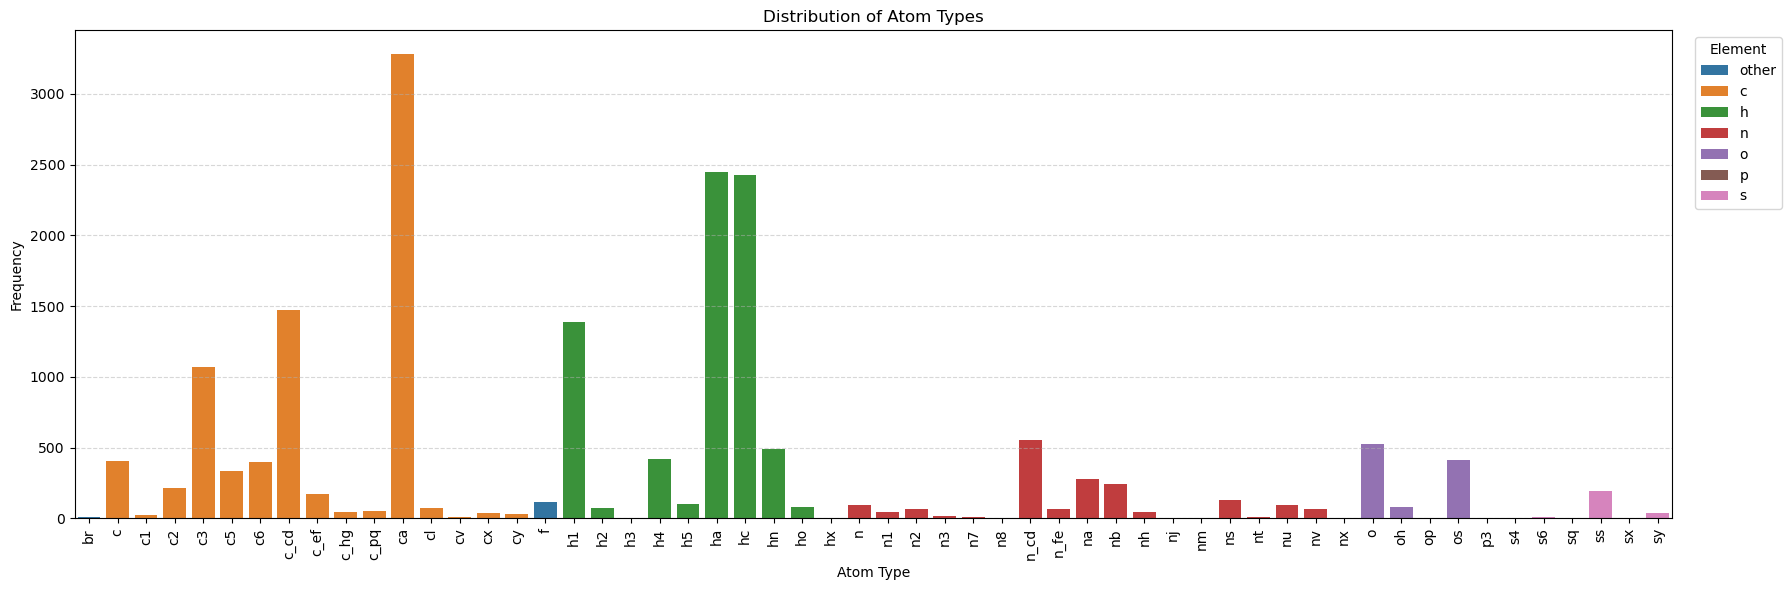


=== ACCURACY ===
0.9973035439137135

=== ATOM_TYPE_ACCURACY ===
{'br': 1.0, 'c': 1.0, 'c1': 1.0, 'c2': 1.0, 'c3': 1.0, 'c5': 1.0, 'c6': 1.0, 'c_cd': 0.9871011541072641, 'c_ef': 0.9941176470588236, 'c_hg': 1.0, 'c_pq': 0.96, 'ca': 1.0, 'cl': 1.0, 'cv': 0.8, 'cx': 1.0, 'cy': 1.0, 'f': 1.0, 'h1': 1.0, 'h2': 1.0, 'h3': 1.0, 'h4': 1.0, 'h5': 1.0, 'ha': 1.0, 'hc': 1.0, 'hn': 1.0, 'ho': 1.0, 'hx': 0.0, 'n': 1.0, 'n1': 1.0, 'n2': 0.984375, 'n3': 1.0, 'n7': 1.0, 'n8': 1.0, 'n_cd': 0.992818671454219, 'n_fe': 1.0, 'na': 0.9963898916967509, 'nb': 1.0, 'nh': 0.9545454545454546, 'nj': 1.0, 'nm': 1.0, 'ns': 1.0, 'nt': 1.0, 'nu': 1.0, 'nv': 1.0, 'nx': 0.0, 'o': 1.0, 'oh': 1.0, 'op': 1.0, 'os': 1.0, 'p3': 0.0, 's4': 1.0, 's6': 1.0, 'sq': 1.0, 'ss': 1.0, 'sx': 0.8, 'sy': 0.6842105263157895}

=== ATOM_TYPE_COUNTS ===
{'br': 9, 'c': 404, 'c1': 23, 'c2': 218, 'c3': 1069, 'c5': 338, 'c6': 396, 'c_cd': 1473, 'c_ef': 170, 'c_hg': 46, 'c_pq': 50, 'ca': 3285, 'cl': 70, 'cv': 10, 'cx': 36, 'cy': 33, 'f': 114, '

In [10]:
from atoMLtype.analysis.accuracy_counts import get_accuracies_and_counts, plot_atom_distribution

# Display distribution of true labels
plot_atom_distribution(pred_record.true_labels)

# Compute and print accuracy metrics
metrics = get_accuracies_and_counts(pred_record)
for k, v in metrics.items():
    print(f"\n=== {k.upper()} ===")
    print(v if not isinstance(v, dict) else dict(sorted(v.items())))

## Part 2. Confusion Matrices for Misclassifications

**Functions from:** `confusionMatrices.py`

### Goals:
- Generate heatmaps for **intra-** and **cross-element** misclassifications
- See how model confuses similar atom types within a chemical context

### Functions:
- `plot_full_confusion_matrices(pred_record)`
- `plot_element_confusion_matrices(pred_record)`

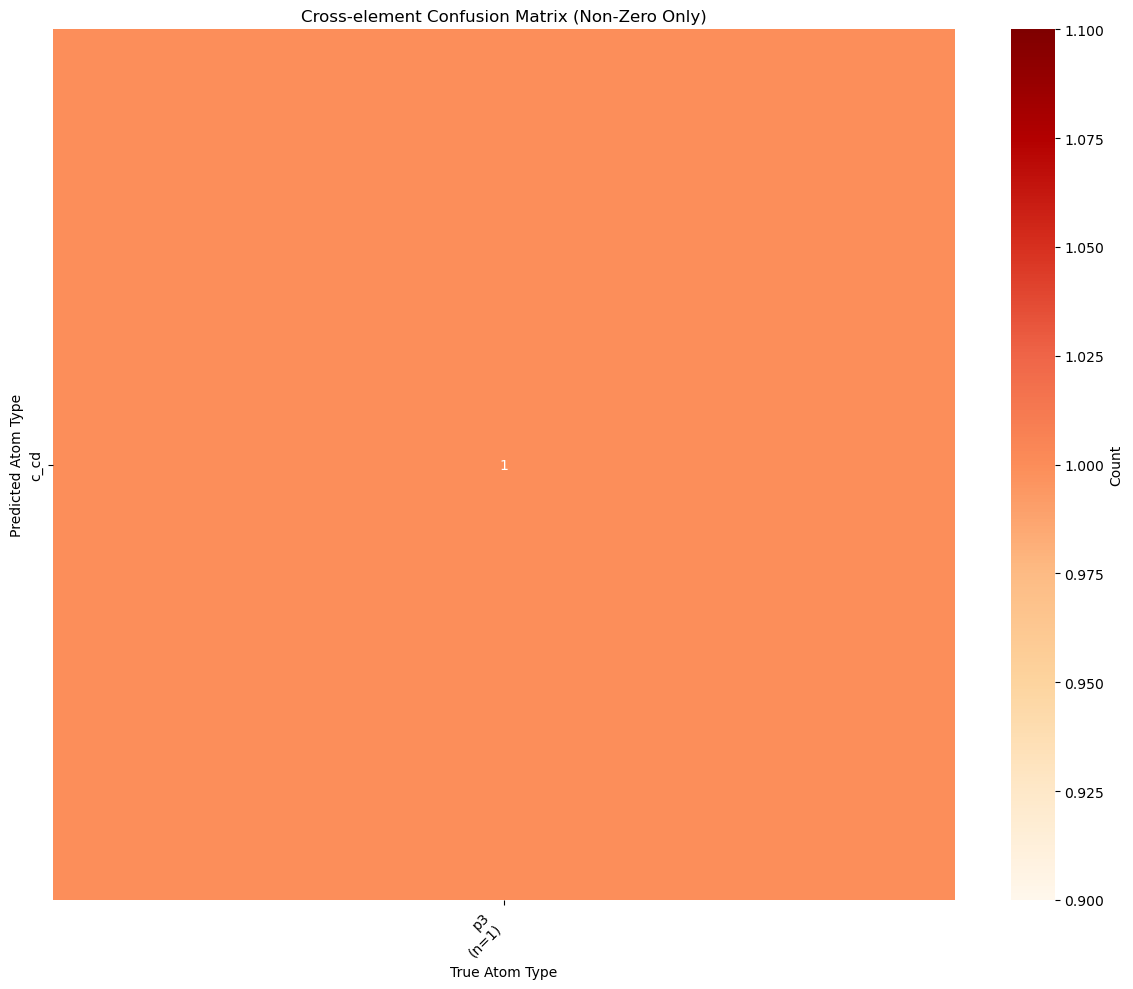

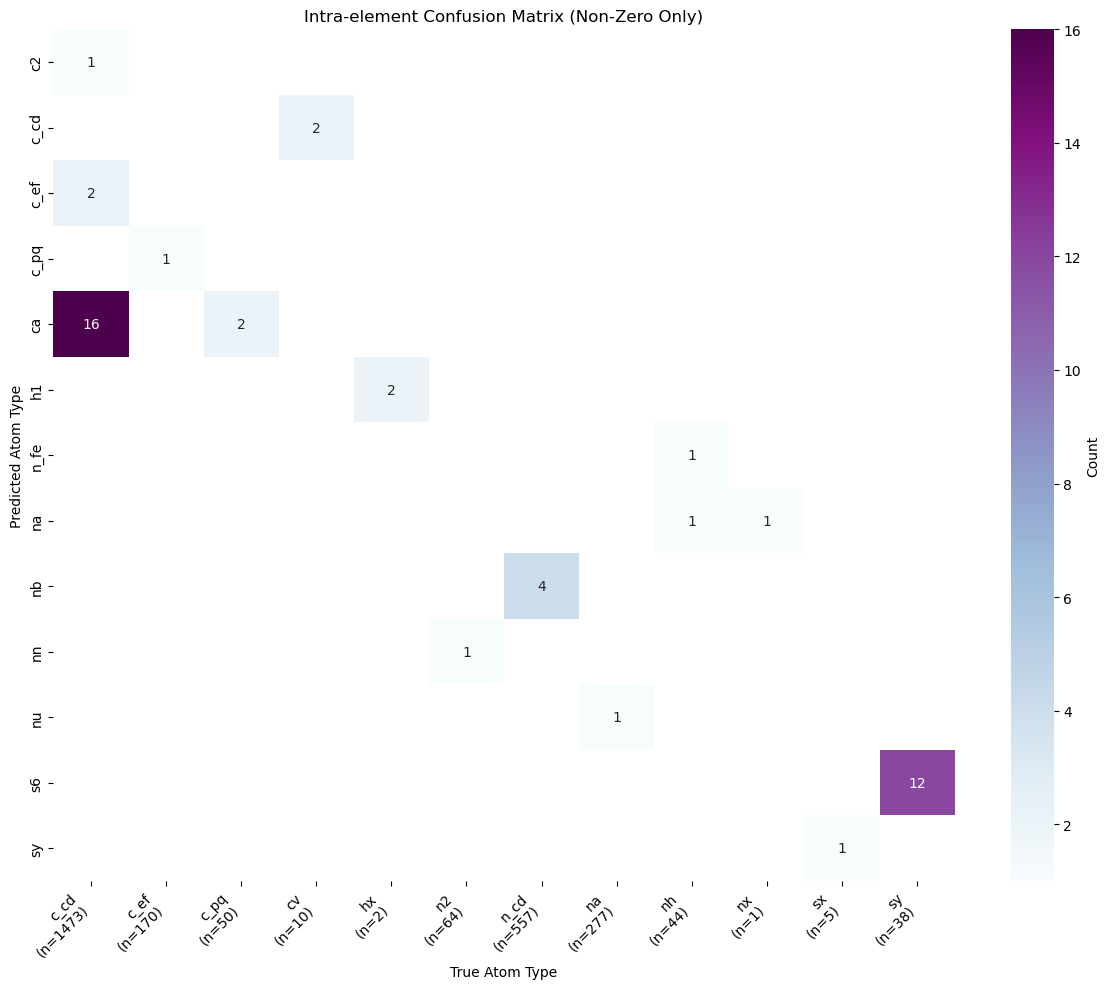

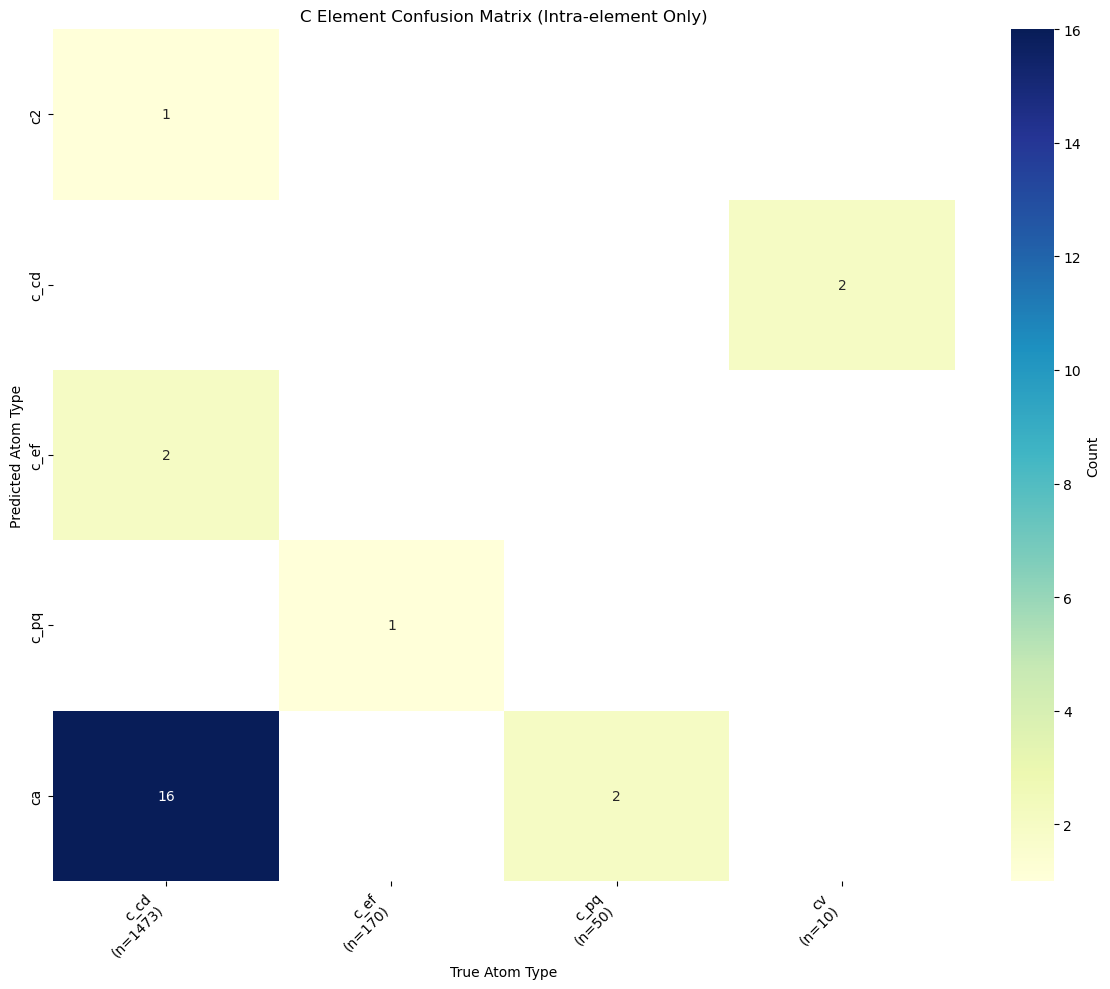

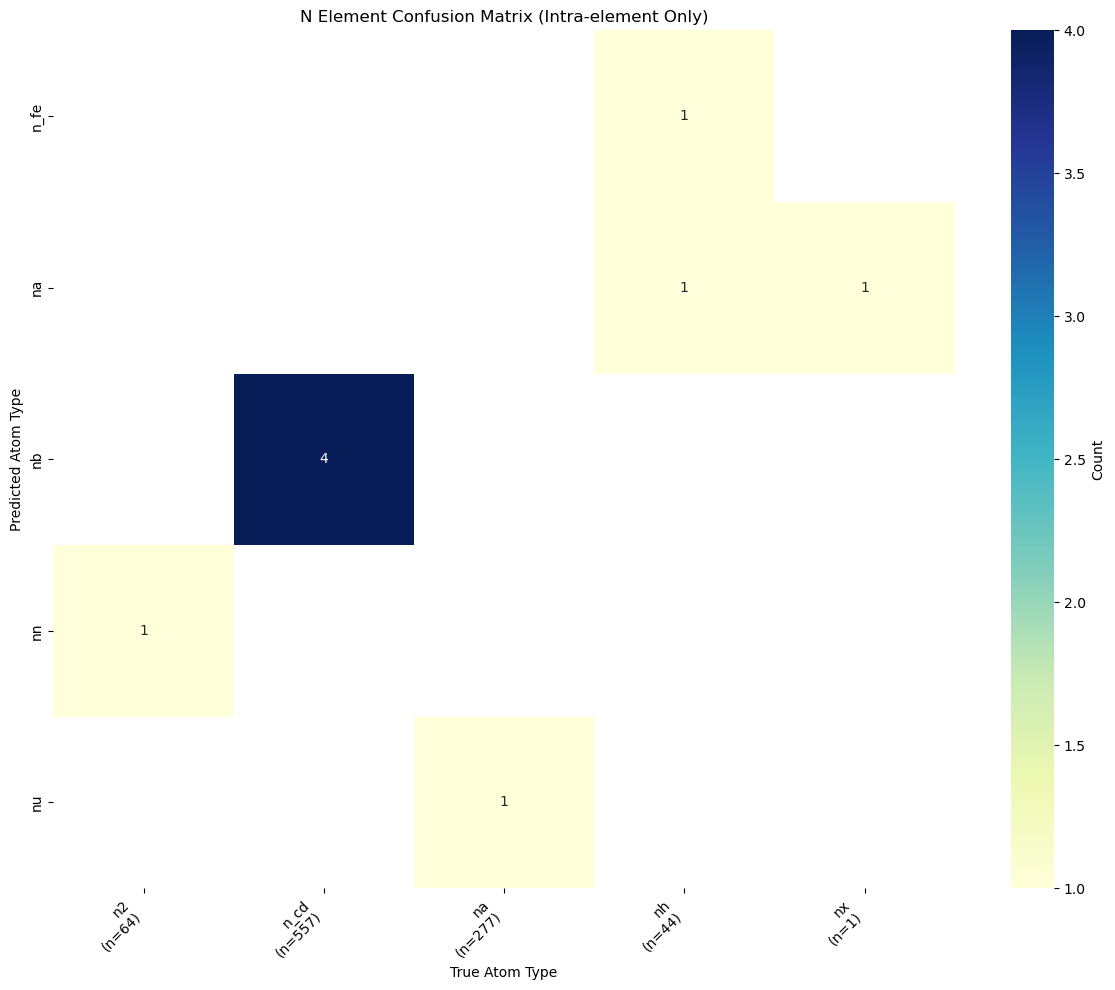

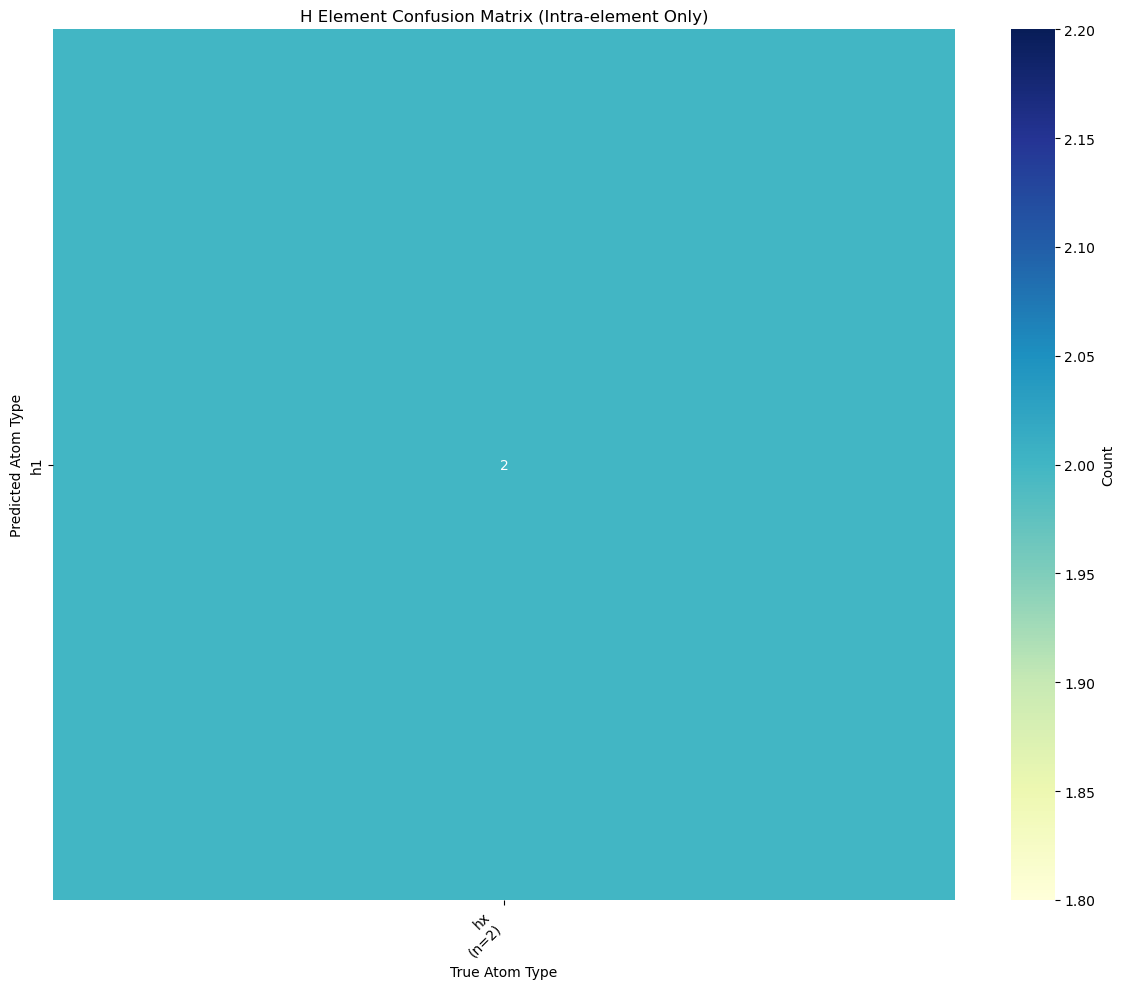

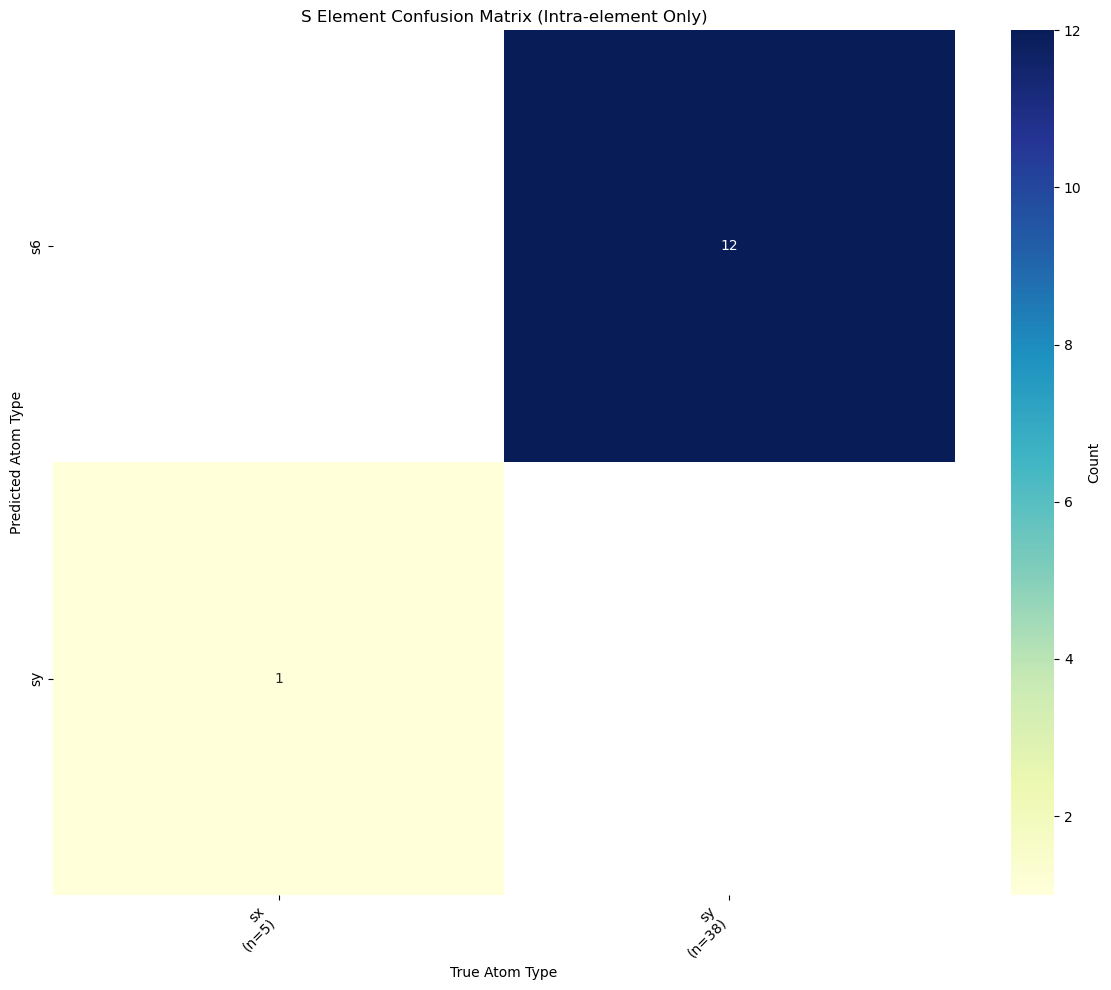

In [11]:
from atoMLtype.analysis.confusionMatrices import plot_full_confusion_matrices, plot_element_confusion_matrices

plot_full_confusion_matrices(pred_record)
plot_element_confusion_matrices(pred_record)

## Part 3. Normalized Heatmaps of All Predictions

**Functions from:** `heatmaps.py`

### Goals:
- Show full row-normalized confusion matrix (%-based)
- Highlight systematic bias in prediction classes

### Functions:
- `plot_full_heatmap(pred_record)`
- `plot_element_heatmap(pred_record)`
- `plot_cross_element_heatmap(pred_record)`

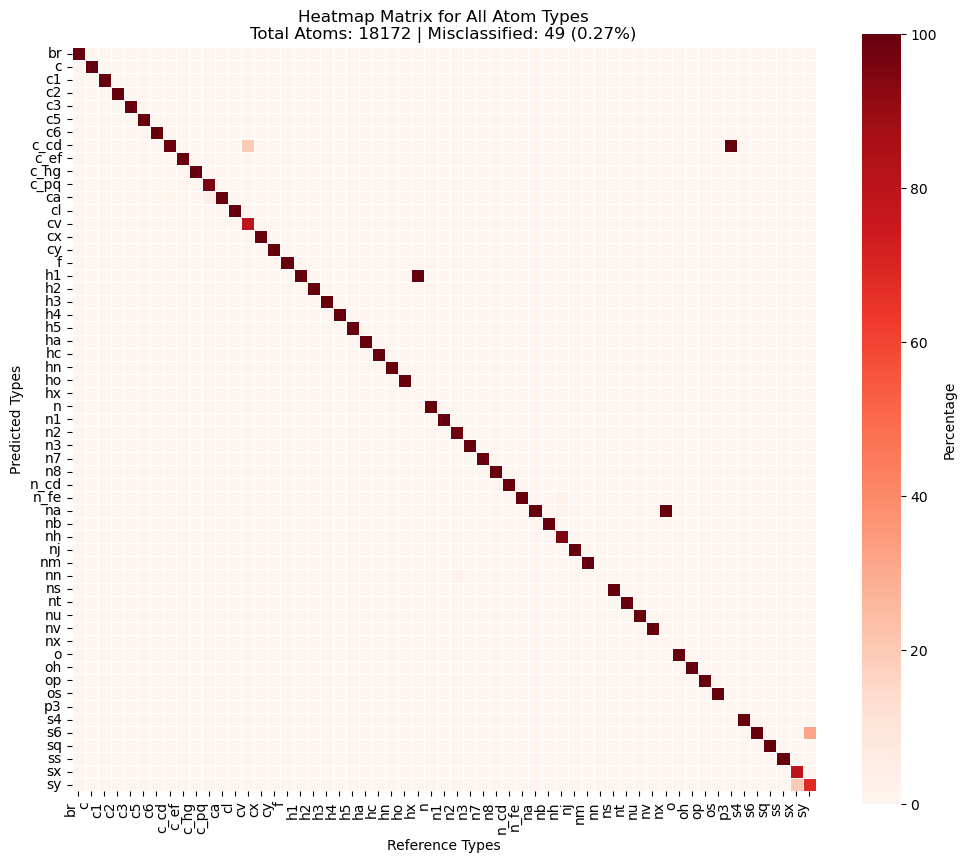

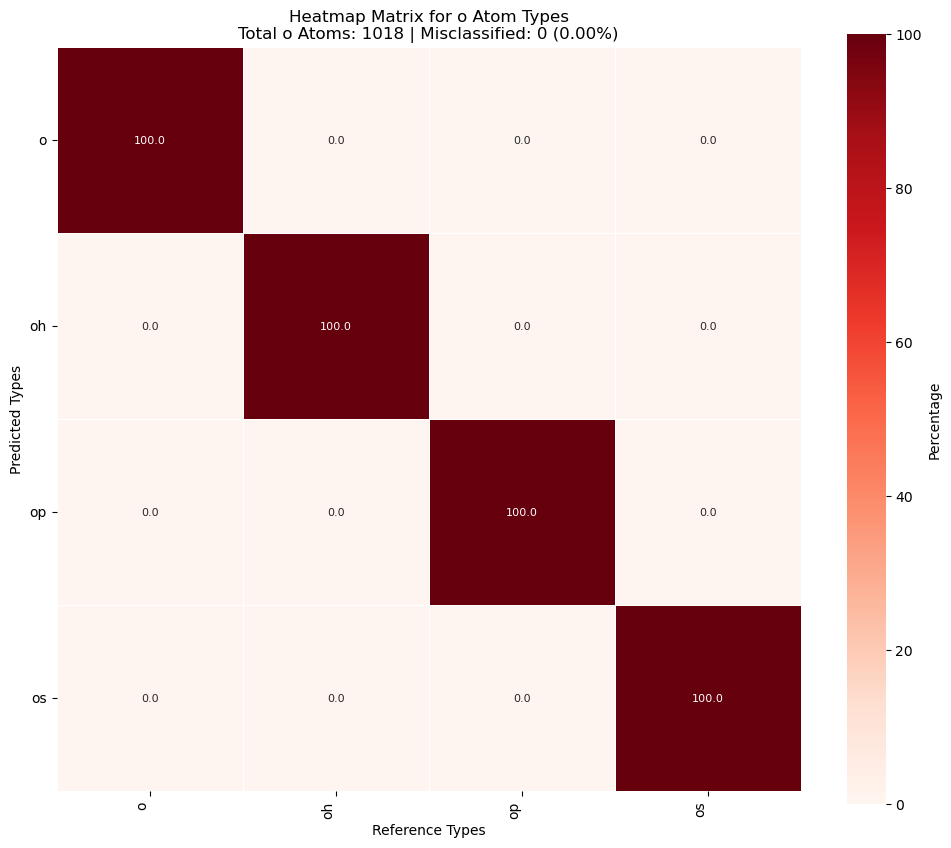

Skipping empty heatmap: Heatmap Matrix for p Atom Types
Total p Atoms: 1 | Misclassified: 1 (100.00%)


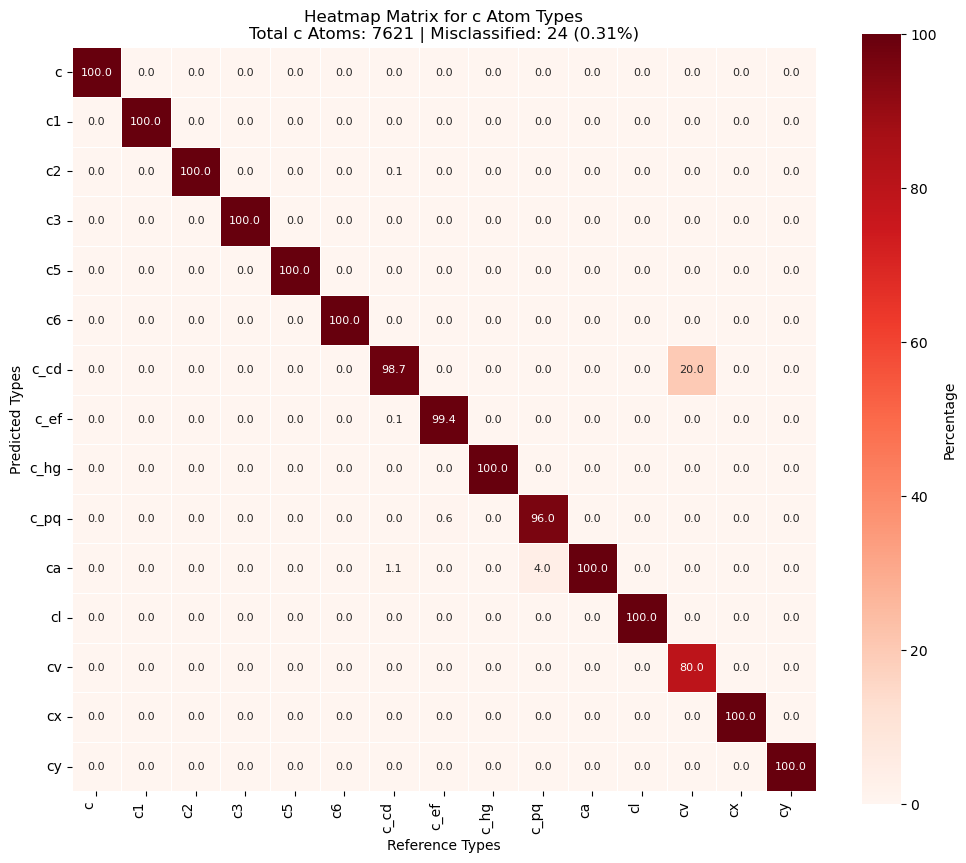

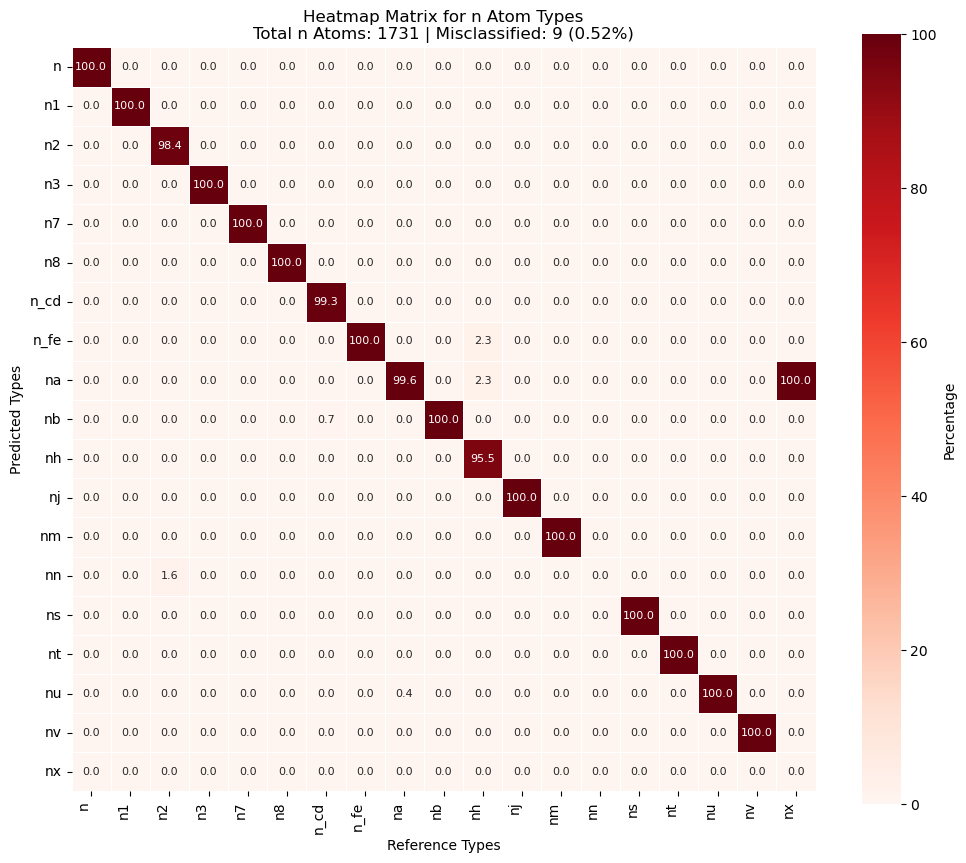

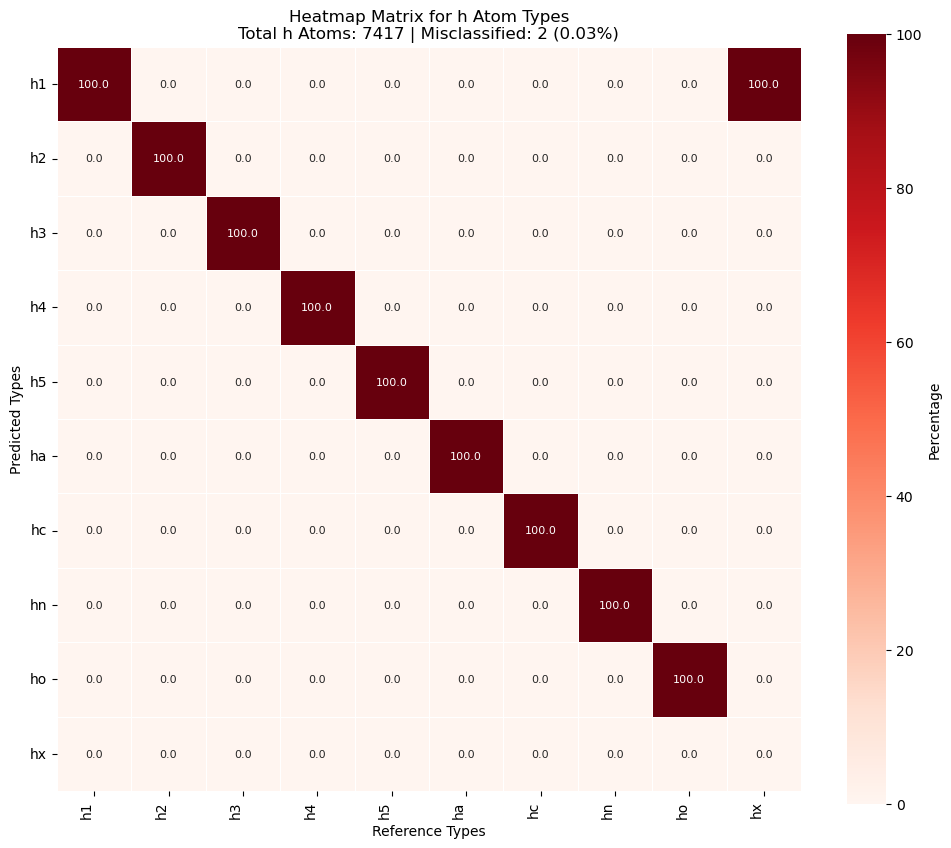

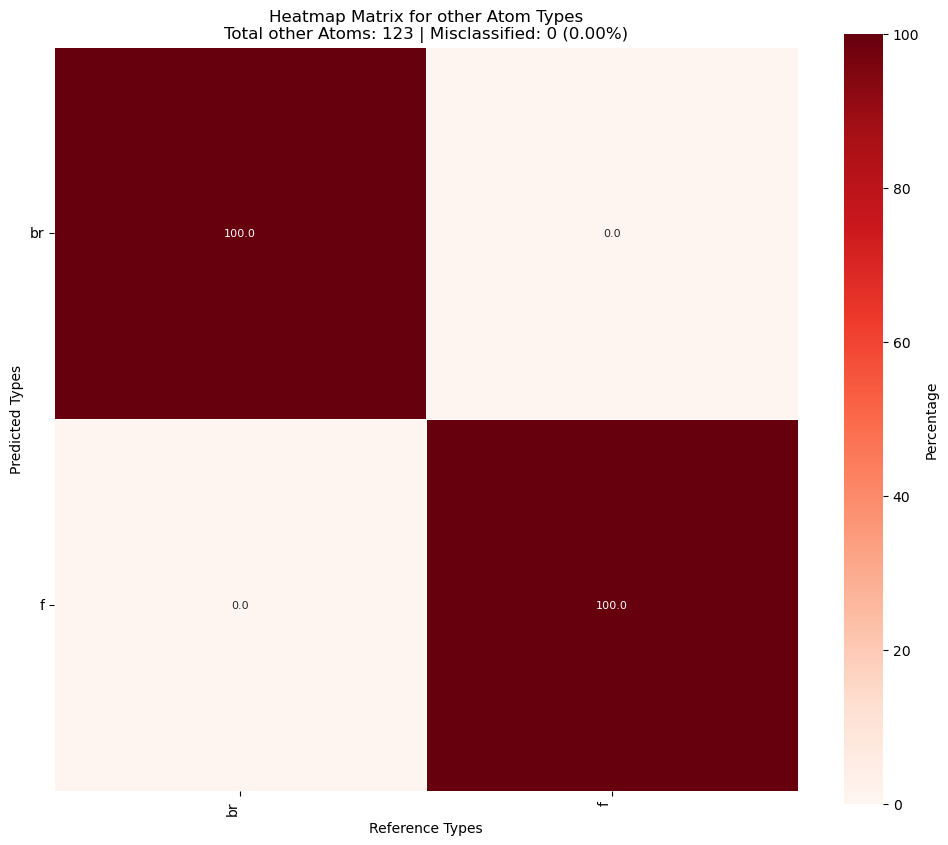

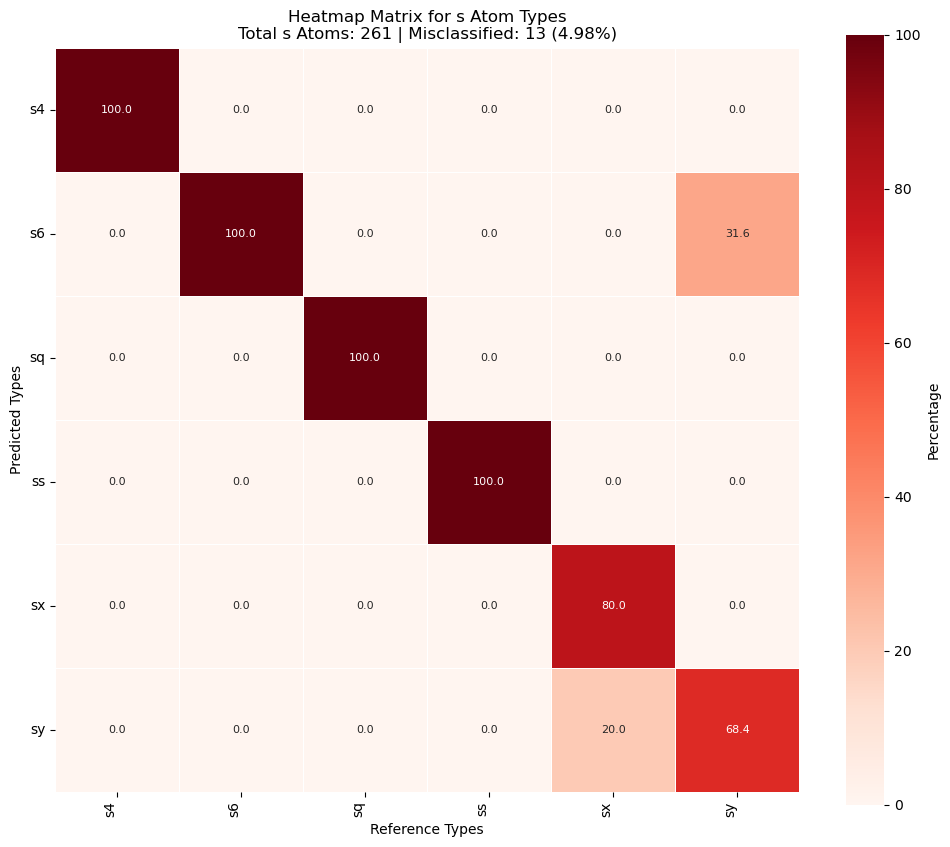

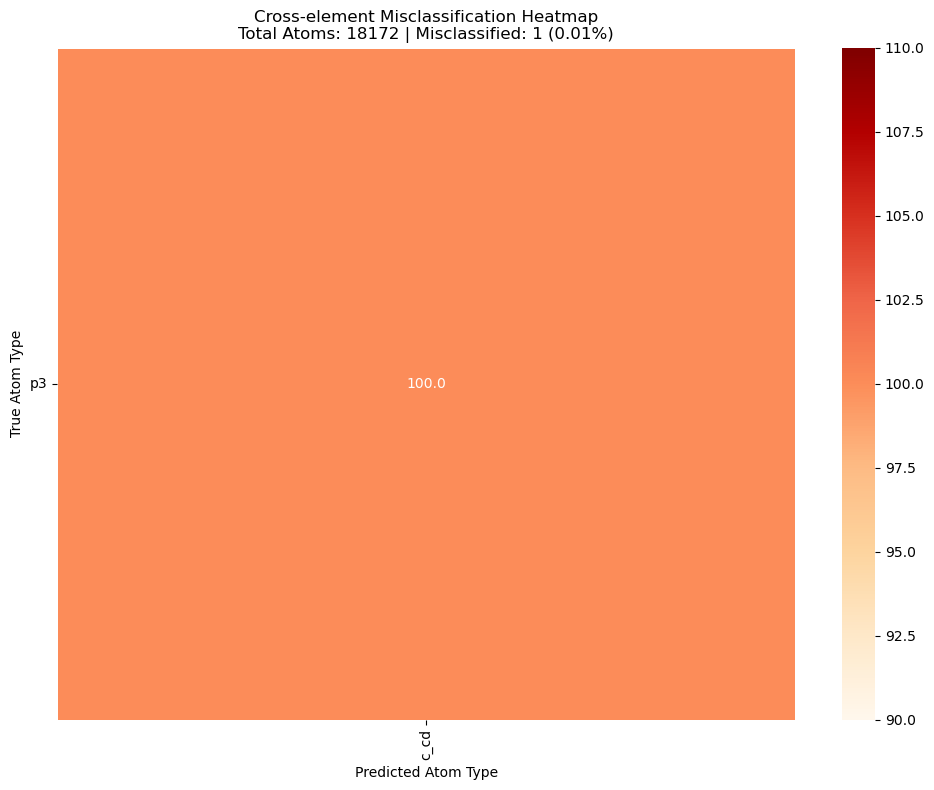

In [12]:
from atoMLtype.analysis.heatmaps import plot_full_heatmap, plot_element_heatmap, plot_cross_element_heatmap

plot_full_heatmap(pred_record)
plot_element_heatmap(pred_record)
plot_cross_element_heatmap(pred_record)

## Part 4. Discrepancy Diagnostics

**Functions from:** `discrepancies.py`

### Goals:
- Quantify errors by molecule and atom type
- Compare element-level performance
- Visualize discrepancy rates and confidence variation

### Functions:
- `plot_confidence_by_pred_label(pred_record)`
- `plot_discrepancy_distribution(pred_record)`
- `plot_element_discrepancy_rate(pred_record)`
- `plot_discrepancy_rate_by_atom_type(pred_record)`

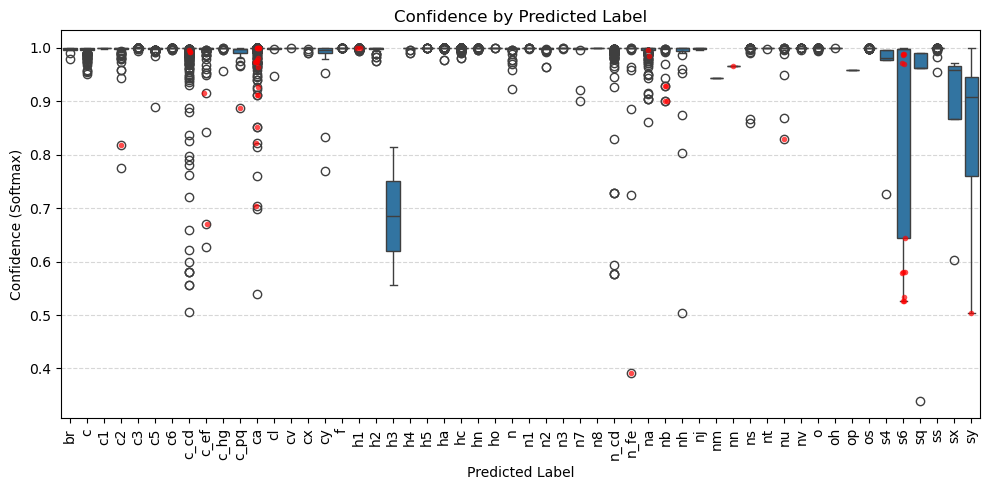

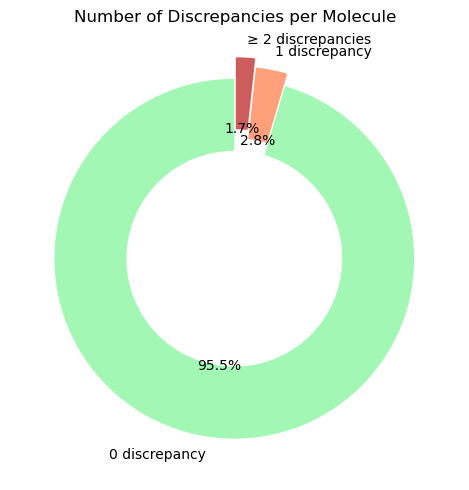

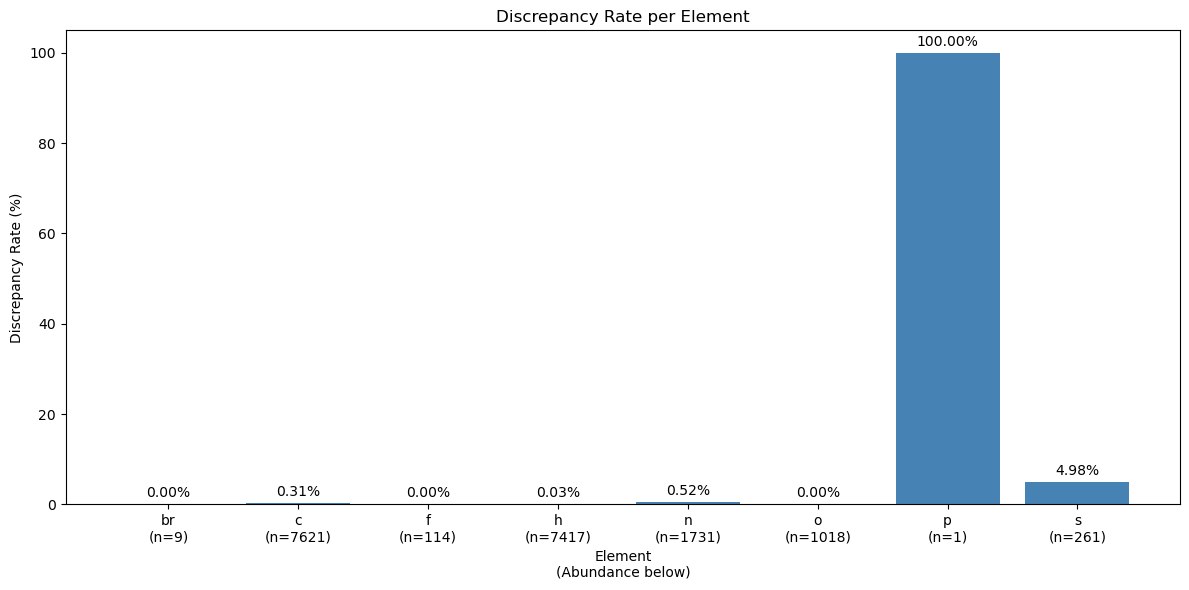

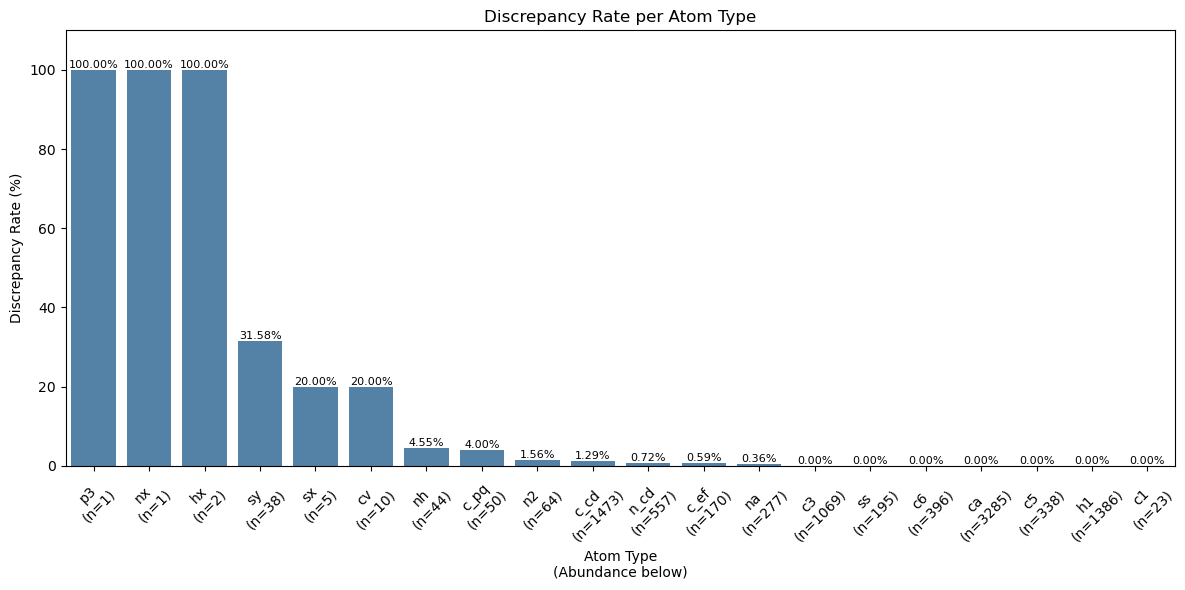

In [15]:
from atoMLtype.analysis.discrepancies import plot_confidence_by_pred_label, plot_discrepancy_distribution, \
                                             plot_element_discrepancy_rate, plot_discrepancy_rate_by_atom_type

plot_confidence_by_pred_label(pred_record, showfliers=True)
plot_discrepancy_distribution(pred_record)
plot_element_discrepancy_rate(pred_record, valid_elements={"c", "h", "o", "n", "s", "p", "cl", "br", "i", "f"})
plot_discrepancy_rate_by_atom_type(pred_record)

## Part 5. Visualizing Embeddings and Highlighting Errors

**Functions from:** `molecule_embeddings.py`

### Goals:
- Project high-dimensional atom embeddings into 2D space (UMAP or TSNE)
- Overlay mismatched atoms
- Render molecule images with annotated atom-type mismatches

### Functions:
- `visualize_prediction_embeddings(pred_record, method='umap', color_by='true_label')`
- `draw_molecule_with_mismatches_labeled(mol, atom_predictions)`

/Users/brobello/Capstone_biovia/Biovia-1/atoMLtype/analysis/molecule_embeddings.py:106: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


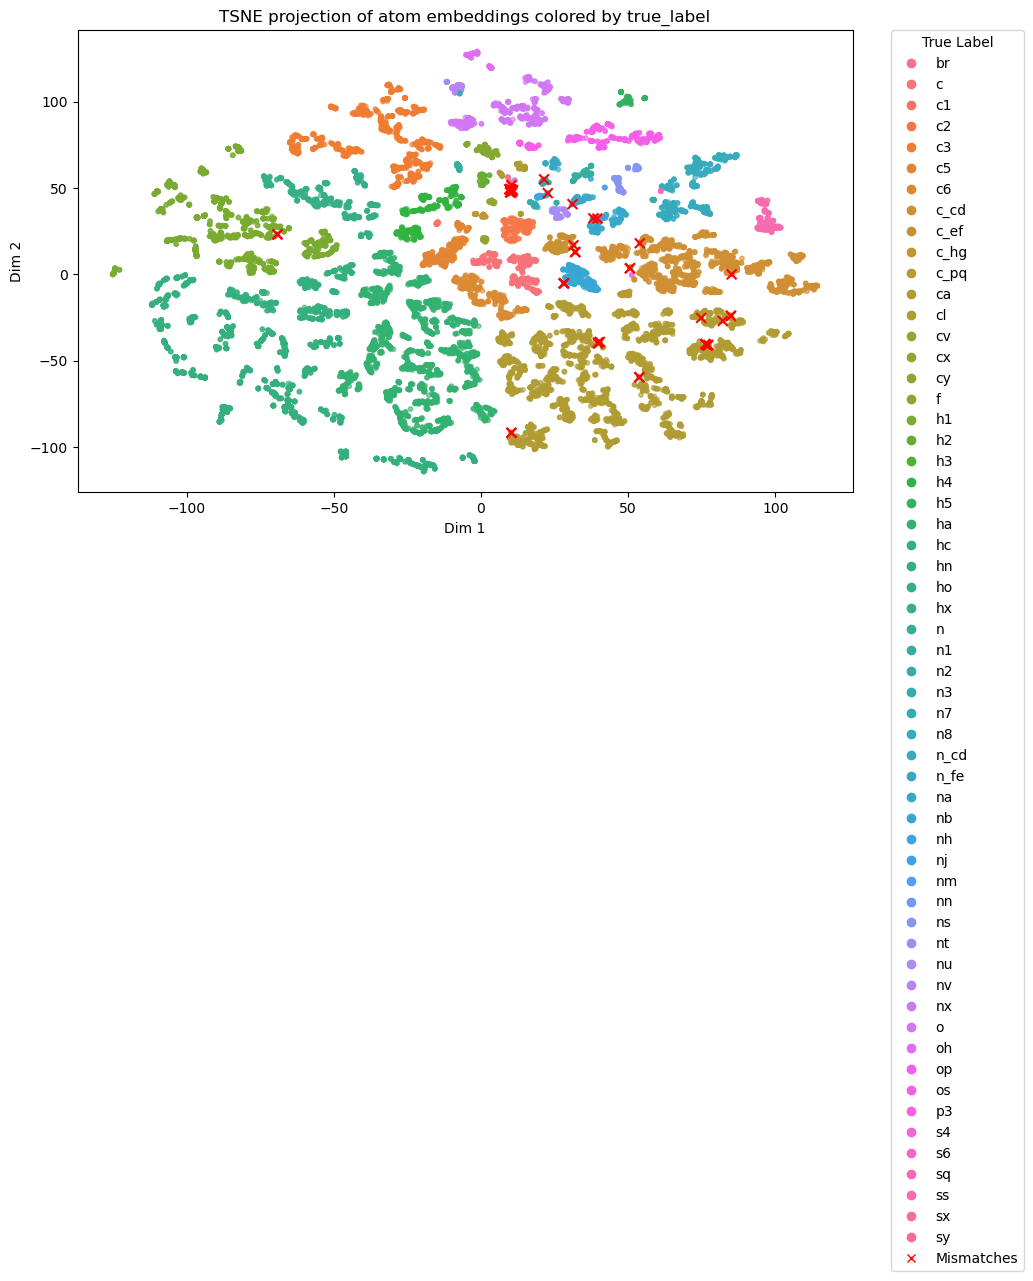

ZINC38337694 atom 3, pred AT na for nh


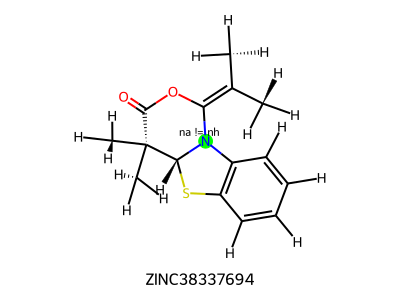

ZINC00334889 atom 12, pred AT sy for sx


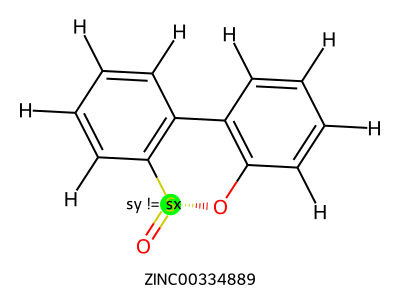

ZINC12146647 atom 9, pred AT ca for c_cd
ZINC12146647 atom 10, pred AT ca for c_cd


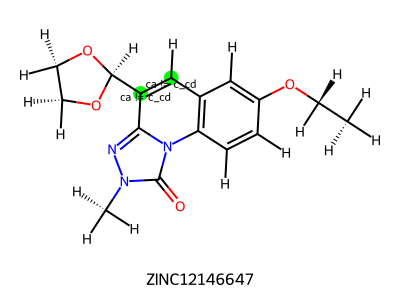

ZINC57218833 atom 3, pred AT ca for c_pq
ZINC57218833 atom 10, pred AT ca for c_pq


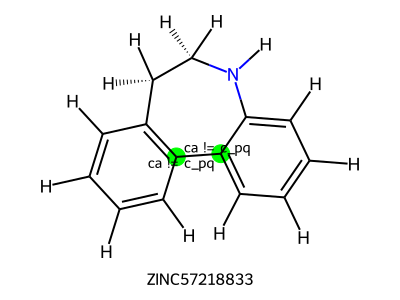

ZINC05179694 atom 4, pred AT s6 for sy


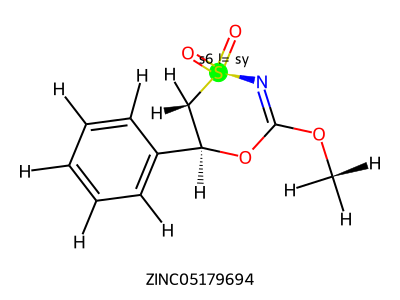

ZINC04338445 atom 10, pred AT s6 for sy


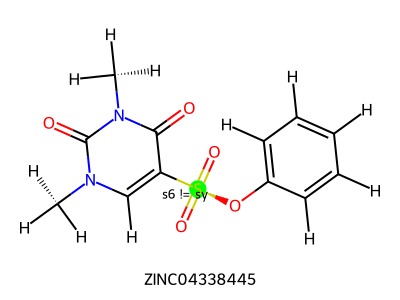

ZINC03847050 atom 2, pred AT ca for c_cd
ZINC03847050 atom 6, pred AT ca for c_cd
ZINC03847050 atom 10, pred AT ca for c_cd


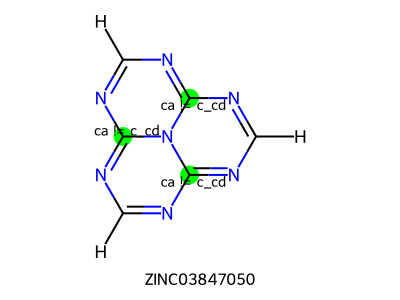

ZINC01629476 atom 3, pred AT ca for c_cd


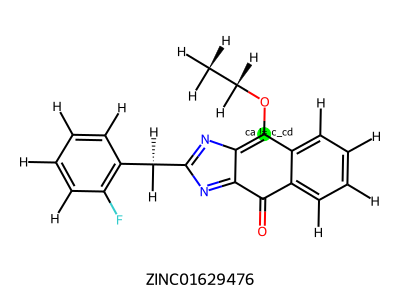

ZINC01557426 atom 9, pred AT nn for n2


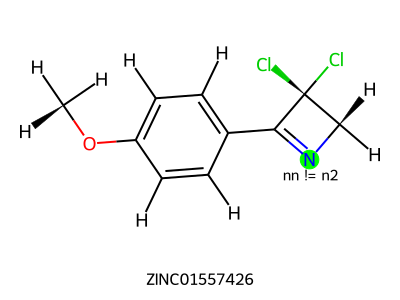

ZINC01723878 atom 8, pred AT s6 for sy


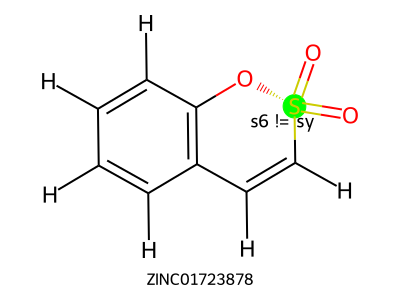

ZINC03861799 atom 6, pred AT c_pq for c_ef
ZINC03861799 atom 7, pred AT ca for c_cd
ZINC03861799 atom 8, pred AT ca for c_cd
ZINC03861799 atom 9, pred AT ca for c_cd
ZINC03861799 atom 10, pred AT ca for c_cd
ZINC03861799 atom 12, pred AT ca for c_cd
ZINC03861799 atom 13, pred AT ca for c_cd


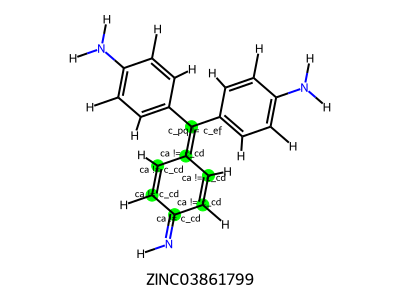

ZINC06068885 atom 1, pred AT c_ef for c_cd
ZINC06068885 atom 2, pred AT c_ef for c_cd


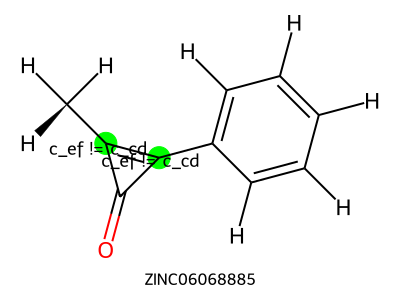

ZINC22183031 atom 10, pred AT c2 for c_cd
ZINC22183031 atom 11, pred AT nu for na


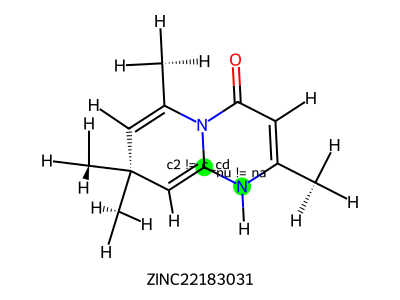

ZINC04946519 atom 3, pred AT s6 for sy


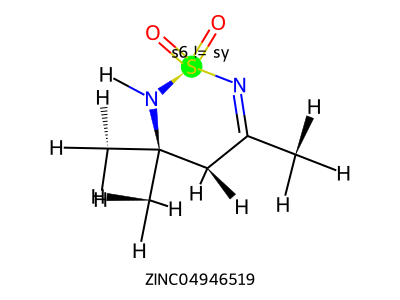

ZINC05179697 atom 7, pred AT s6 for sy


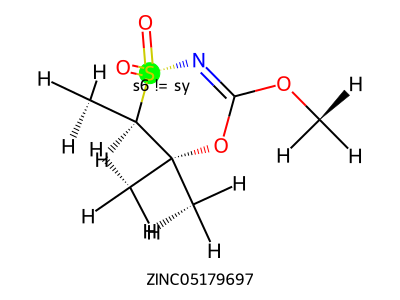

ZINC13207874 atom 10, pred AT ca for c_cd
ZINC13207874 atom 11, pred AT ca for c_cd


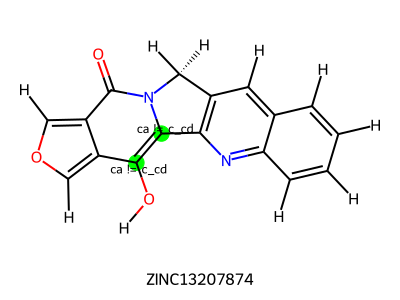

ZINC05778327 atom 5, pred AT n_fe for nh


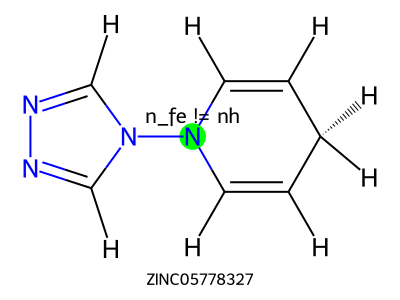

ZINC04457505 atom 8, pred AT nb for n_cd
ZINC04457505 atom 9, pred AT ca for c_cd
ZINC04457505 atom 10, pred AT ca for c_cd
ZINC04457505 atom 11, pred AT nb for n_cd


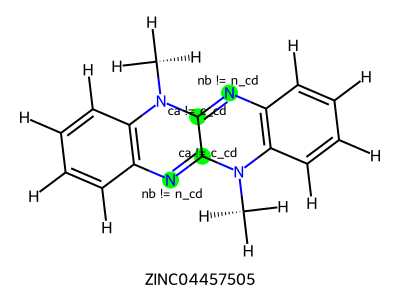

ZINC00162318 atom 9, pred AT s6 for sy


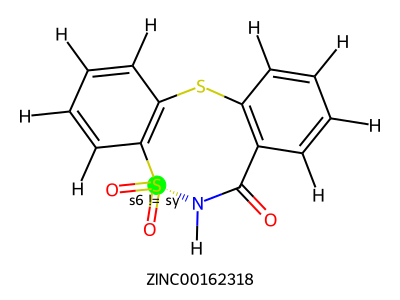

ZINC01723346 atom 6, pred AT nb for n_cd
ZINC01723346 atom 11, pred AT nb for n_cd


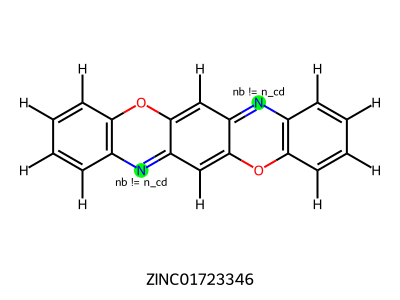

ZINC49102757 atom 5, pred AT s6 for sy


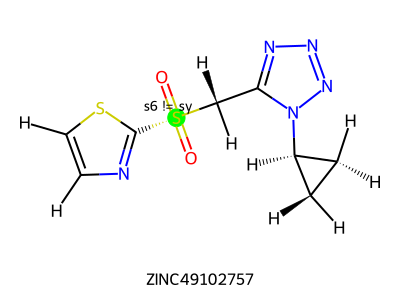

ZINC01711387 atom 3, pred AT s6 for sy


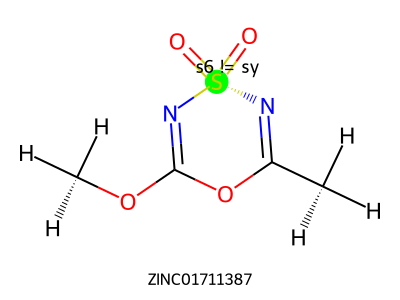

ZINC00399453 atom 6, pred AT s6 for sy


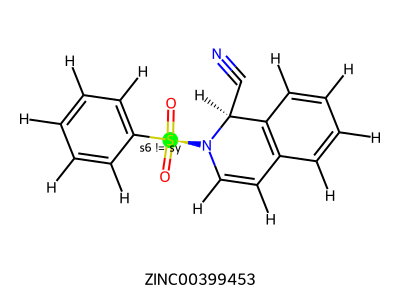

ZINC05369575 atom 12, pred AT c_cd for p3


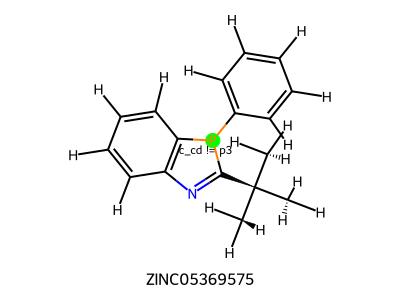

ZINC02024584 atom 10, pred AT na for nx
ZINC02024584 atom 23, pred AT h1 for hx
ZINC02024584 atom 24, pred AT h1 for hx


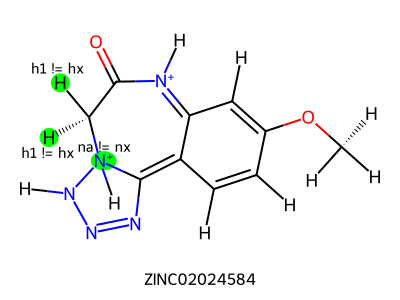

ZINC01765084 atom 0, pred AT c_cd for cv
ZINC01765084 atom 1, pred AT c_cd for cv


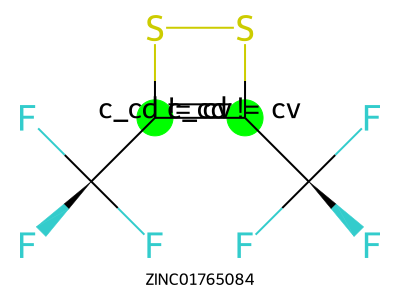

ZINC02576768 atom 6, pred AT s6 for sy


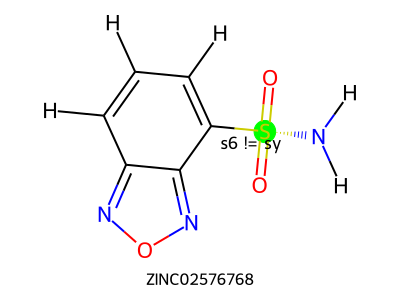

ZINC08782853 atom 6, pred AT s6 for sy


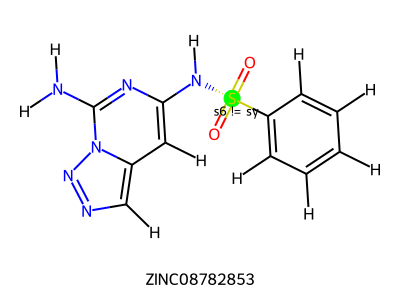

ZINC39053905 atom 6, pred AT s6 for sy


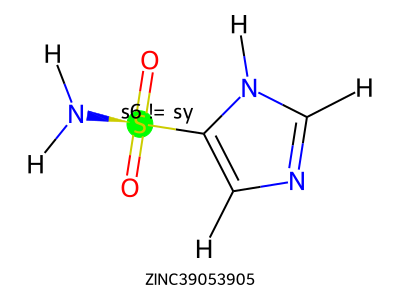

In [14]:
from atoMLtype.analysis.molecule_embeddings import visualize_prediction_embeddings, draw_molecule_with_mismatches_labeled

visualize_prediction_embeddings(pred_record, method="tsne", color_by="true_label")

for mol_name, atom_preds in pred_record.mismatched_molecules.items():
    for atom_pred in atom_preds:
        if not atom_pred.pred_label == atom_pred.true_label:
            print(f"{mol_name} atom {atom_pred.atom_idx_in_mol}, pred AT {atom_pred.pred_label} for {atom_pred.true_label}")
    mol = zinc_dataset.get_mol(mol_name)

    img = draw_molecule_with_mismatches_labeled(mol, atom_preds)
    display(img)